In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# подготовка данных
import pandas as pd
comments = pd.read_csv('/content/drive/MyDrive/Диплом_Артема_Хугаева/cleaned_comments.csv')

import re

# 1. Копируем исходный датасет
comments_sent = comments.copy()

# 2. Приводим id к строкам, чтобы потом нормально merge-ить
comments_sent["id"] = comments_sent["id"].astype(str)
comments_sent["post_id"] = comments_sent["post_id"].astype(str)

# 3. Убираем комментарии без текста
comments_sent = comments_sent.dropna(subset=["text"]).copy()

# 4. Нормализуем текст минимально
def normalize_for_sentiment(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)  # убираем лишние пробелы и переносы
    text = text.strip()
    return text

comments_sent["text_for_sentiment"] = comments_sent["text"].apply(normalize_for_sentiment)

# 5. Убираем пустые строки после чистки
comments_sent = comments_sent[comments_sent["text_for_sentiment"] != ""].copy()

# 6. Пересчитываем длину и количество слов на всякий случай
comments_sent["text_length_clean"] = comments_sent["text_for_sentiment"].str.len()
comments_sent["word_count_clean"] = comments_sent["text_for_sentiment"].str.split().str.len()

# 7. Убираем слишком короткие комментарии
comments_sent = comments_sent[
    (comments_sent["text_length_clean"] >= 20) &
    (comments_sent["word_count_clean"] >= 3)
].copy()

# 8. Убираем дубли комментариев по id
comments_sent = comments_sent.drop_duplicates(subset=["id"]).copy()

# 9. Оставляем нужные колонки
comments_sent = comments_sent[
    [
        "id",
        "post_id",
        "author",
        "author_id",
        "indent",
        "rating",
        "text_for_sentiment",
        "text_length_clean",
        "word_count_clean",
        "is_reply"
    ]
].copy()

print(comments_sent.shape)
comments_sent.head()

(144883, 10)


,id,post_id,author,author_id,indent,rating,text_for_sentiment,text_length_clean,word_count_clean,is_reply
0,376393288,13488271,Elya20,804806.0,0,460.0,Чтоб все получилось! Чтоб массово люди начали ...,75,11,False
1,376434095,13488271,Archi77,1008009.0,1,17.0,От какой именно? От какого именно из тысяч вид...,188,34,True
2,376435162,13488271,PlagueMen,1297286.0,2,5.0,"В чем же и фишка, вакцина не от всех видов рак...",202,35,True
3,376443914,13488271,Ghostevg,844934.0,3,13.0,Препарат предназначен для борьбы с меланомой и...,250,39,True
4,376454356,13488271,PlagueMen,1297286.0,4,3.0,Выпускается серия вакцин для меланомы (как в с...,213,34,True


In [4]:
posts_lda_ready = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_lda_done.csv") # датасет с темами финально

In [5]:
# 1. Берём из posts только нужные колонки
posts_topics = posts_lda_ready[["post_id", "date", "topic"]].copy()

# 2. Приводим post_id к одному типу
posts_topics["post_id"] = posts_topics["post_id"].astype(str)
comments_sent["post_id"] = comments_sent["post_id"].astype(str)

# 3. Склеиваем комментарии с темами и датами постов
comments_sent = comments_sent.merge(
    posts_topics,
    on="post_id",
    how="left"
)

# 4. Убираем комментарии, где не нашлась тема или дата
comments_sent = comments_sent.dropna(subset=["topic", "date"]).copy()

# 5. Приводим типы
comments_sent["topic"] = comments_sent["topic"].astype(int)
comments_sent["date"] = pd.to_datetime(comments_sent["date"], errors="coerce")
comments_sent = comments_sent.dropna(subset=["date"]).copy()

# 6. Достаём год
comments_sent["year"] = comments_sent["date"].dt.year

print(comments_sent.shape)
print(comments_sent["topic"].value_counts().sort_index())
print(comments_sent["year"].value_counts().sort_index())

(108325, 13)
topic
1    59762
2    29749
3     4495
4    11088
5     3231
Name: count, dtype: int64
year
2020     5628
2021    46017
2022    30932
2023     7595
2024     7813
2025    10083
2026      257
Name: count, dtype: int64


In [7]:
comments_sent.to_csv(
    "/content/drive/MyDrive/Диплом_Артема_Хугаева/comments_sent.csv",
    index=False
)

In [9]:
# сентимент размеченный бертом

comments_sent_labeled = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/comments_sentiment_model.csv")


In [10]:
import numpy as np
import pandas as pd

sentiment_df = comments_sent_labeled.copy()

sentiment_df = sentiment_df[
    sentiment_df["sentiment"].isin(["positive", "negative", "neutral"])
].copy()

sentiment_df["sentiment_num"] = sentiment_df["sentiment"].map({
    "negative": -1,
    "neutral": 0,
    "positive": 1
})

sentiment_df["sentiment_weighted"] = np.where(
    sentiment_df["sentiment"] == "positive",
    sentiment_df["sentiment_score"],
    np.where(
        sentiment_df["sentiment"] == "negative",
        -sentiment_df["sentiment_score"],
        0
    )
)

sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")
sentiment_df = sentiment_df.dropna(subset=["date", "topic", "year"]).copy()

sentiment_df["topic"] = sentiment_df["topic"].astype(int)
sentiment_df["year"] = sentiment_df["year"].astype(int)

In [10]:
sentiment_df["sentiment"].value_counts(normalize=True).round(3)

,proportion
sentiment,
neutral,0.726
negative,0.246
positive,0.027


In [24]:
# SQ2: sentiment по темам

topic_sent_counts = pd.crosstab(
    sentiment_df["topic"],
    sentiment_df["sentiment"]
)

topic_sent_counts

sentiment,negative,neutral,positive
topic,,,
1,14182,40298,1597
2,7402,20553,636
3,793,3326,94
4,2238,8066,263
5,613,2121,191


In [25]:
topic_sent_props = pd.crosstab(
    sentiment_df["topic"],
    sentiment_df["sentiment"],
    normalize="index"
).round(3)

topic_sent_props

sentiment,negative,neutral,positive
topic,,,
1,0.253,0.719,0.028
2,0.259,0.719,0.022
3,0.188,0.789,0.022
4,0.212,0.763,0.025
5,0.210,0.725,0.065


In [26]:
topic_sent_mean = (
    sentiment_df
    .groupby("topic")["sentiment_weighted"]
    .mean()
    .round(3)
)

topic_sent_mean

,sentiment_weighted
topic,
1,-0.187
2,-0.201
3,-0.137
4,-0.156
5,-0.120


In [27]:
#Статистический тест chi-square

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(topic_sent_counts)

chi2, p, dof

(np.float64(394.1393272850731), np.float64(3.3579056707576394e-80), 8)

In [28]:
n = topic_sent_counts.to_numpy().sum()
min_dim = min(topic_sent_counts.shape) - 1

cramers_v = (chi2 / (n * min_dim)) ** 0.5

cramers_v

np.float64(0.04387500434859247)

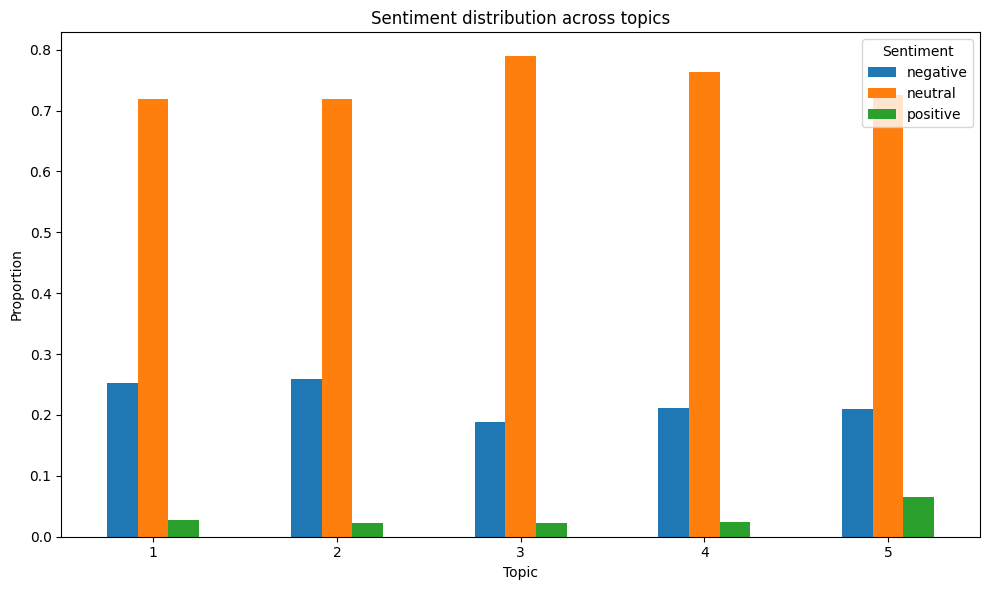

In [29]:
import matplotlib.pyplot as plt

topic_sent_props = pd.crosstab(
    sentiment_df["topic"],
    sentiment_df["sentiment"],
    normalize="index"
).round(3)

topic_sent_props = topic_sent_props[["negative", "neutral", "positive"]]

topic_sent_props.plot(kind="bar", figsize=(10, 6))

plt.title("Sentiment distribution across topics")
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

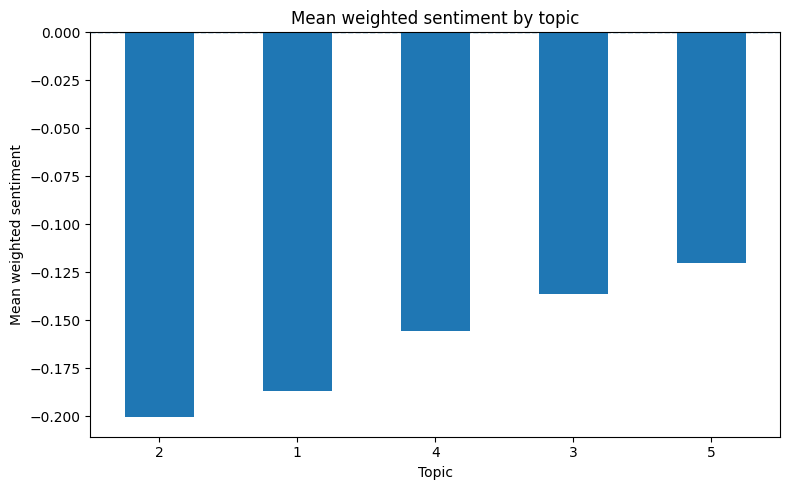

In [30]:
import matplotlib.pyplot as plt

topic_mean_sentiment = (
    sentiment_df
    .groupby("topic")["sentiment_weighted"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

topic_mean_sentiment.plot(kind="bar")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Mean weighted sentiment by topic")
plt.xlabel("Topic")
plt.ylabel("Mean weighted sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

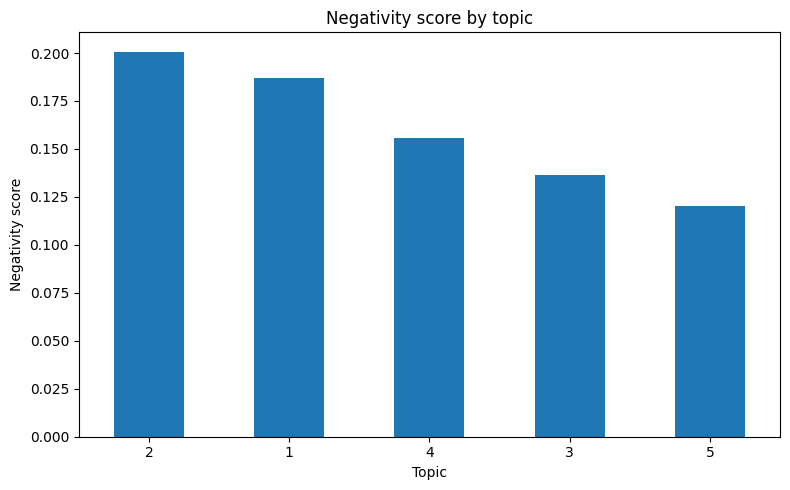

In [31]:
import matplotlib.pyplot as plt

topic_negativity = (
    sentiment_df
    .groupby("topic")["sentiment_weighted"]
    .mean()
    .mul(-1)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

topic_negativity.plot(kind="bar")

plt.title("Negativity score by topic")
plt.xlabel("Topic")
plt.ylabel("Negativity score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# > 2  → в этой теме этого sentiment больше, чем ожидалось
# < -2 → в этой теме этого sentiment меньше, чем ожидалось
# около 0 → примерно как ожидалось

import pandas as pd
import numpy as np

expected_df = pd.DataFrame(
    expected,
    index=topic_sent_counts.index,
    columns=topic_sent_counts.columns
)

std_residuals = (topic_sent_counts - expected_df) / np.sqrt(expected_df)

std_residuals.round(2)

sentiment,negative,neutral,positive
topic,,,
1,3.09,-2.16,1.89
2,4.24,-1.50,-5.05
3,-7.61,4.80,-1.91
4,-7.17,4.45,-1.42
5,-4.02,-0.08,12.51


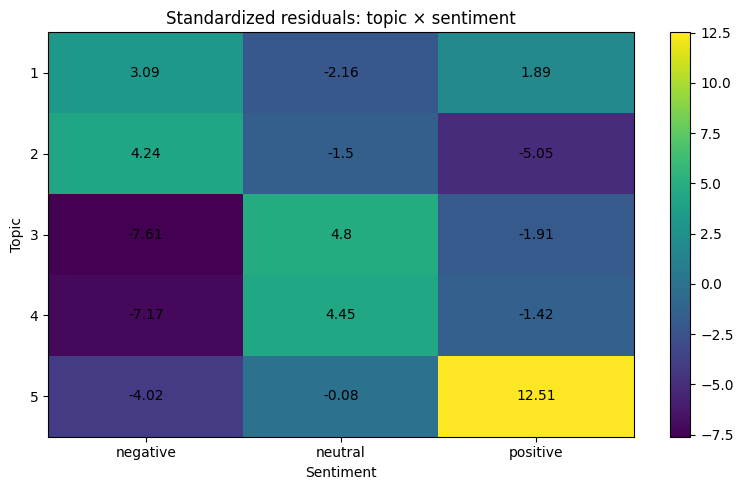

In [33]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(std_residuals.values, aspect="auto")

ax.set_xticks(np.arange(len(std_residuals.columns)))
ax.set_xticklabels(std_residuals.columns)

ax.set_yticks(np.arange(len(std_residuals.index)))
ax.set_yticklabels(std_residuals.index)

for i in range(std_residuals.shape[0]):
    for j in range(std_residuals.shape[1]):
        ax.text(
            j, i,
            round(std_residuals.iloc[i, j], 2),
            ha="center", va="center"
        )

ax.set_title("Standardized residuals: topic × sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Topic")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

The chi-square test showed a statistically significant association between topic and sentiment, χ²(8) = 394.14, p < .001. However, Cramer’s V = 0.044 indicates that the association is weak. Standardized residuals show that Topics 1 and 2 contain more negative comments than expected, Topics 3 and 4 are more neutral and less negative, while Topic 5 is characterized by a substantially higher proportion of positive comments.

In [34]:
#SQ3: sentiment over time
sentiment_df_main = sentiment_df[sentiment_df["year"] < 2026].copy() # убираем 2026 так как только начало года
year_sent_counts = pd.crosstab(
    sentiment_df_main["year"],
    sentiment_df_main["sentiment"]
)

year_sent_counts

sentiment,negative,neutral,positive
year,,,
2020,941,4272,120
2021,11003,31950,984
2022,7049,20661,1074
2023,1667,5193,191
2024,1829,5380,195
2025,2684,6736,205


In [35]:
year_sent_props = pd.crosstab(
    sentiment_df_main["year"],
    sentiment_df_main["sentiment"],
    normalize="index"
).round(3)

year_sent_props = year_sent_props[["negative", "neutral", "positive"]]

year_sent_props

sentiment,negative,neutral,positive
year,,,
2020,0.176,0.801,0.023
2021,0.250,0.727,0.022
2022,0.245,0.718,0.037
2023,0.236,0.736,0.027
2024,0.247,0.727,0.026
2025,0.279,0.700,0.021


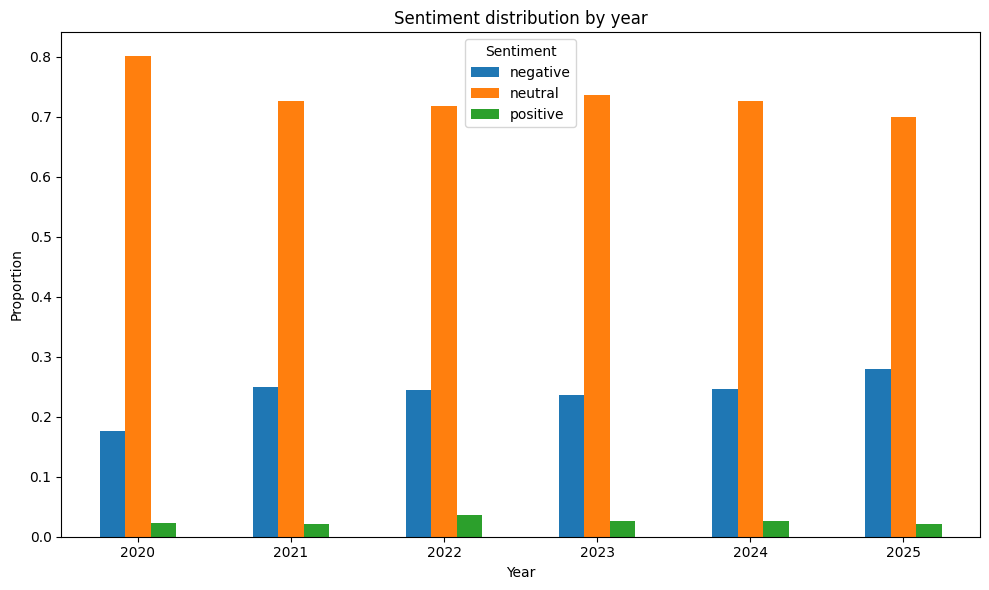

In [36]:
import matplotlib.pyplot as plt

year_sent_props.plot(kind="bar", figsize=(10, 6))

plt.title("Sentiment distribution by year")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [37]:
from scipy.stats import chi2_contingency

chi2_year, p_year, dof_year, expected_year = chi2_contingency(year_sent_counts)

chi2_year, p_year, dof_year

(np.float64(370.104224348517), np.float64(2.144330926916871e-73), 10)

In [38]:
n_year = year_sent_counts.to_numpy().sum()
min_dim_year = min(year_sent_counts.shape) - 1

cramers_v_year = (chi2_year / (n_year * min_dim_year)) ** 0.5

cramers_v_year

np.float64(0.04256590316563218)

In [39]:
year_mean_sentiment = (
    sentiment_df_main
    .groupby("year")["sentiment_weighted"]
    .mean()
)

year_mean_sentiment

,sentiment_weighted
year,
2020,-0.129260
2021,-0.191533
2022,-0.174047
2023,-0.172474
2024,-0.182100
2025,-0.217292


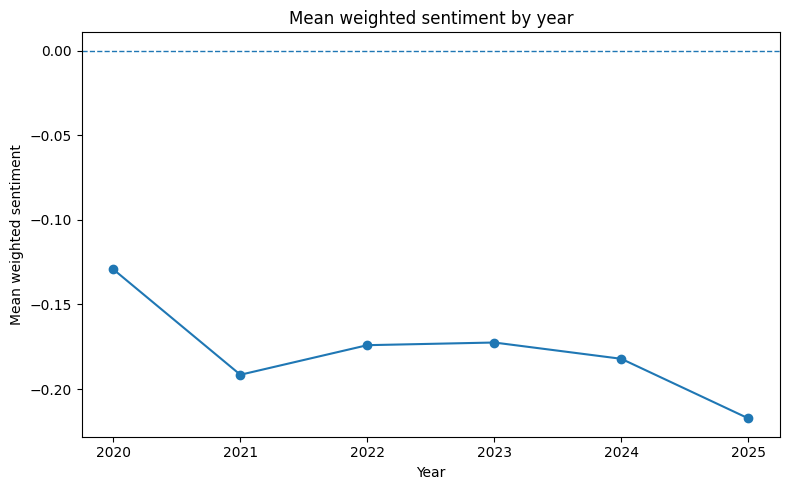

In [40]:
plt.figure(figsize=(8, 5))

year_mean_sentiment.plot(marker="o")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Mean weighted sentiment by year")
plt.xlabel("Year")
plt.ylabel("Mean weighted sentiment")
plt.tight_layout()
plt.show()

The year 2026 was excluded from the main temporal analysis because the observation period for this year was incomplete and contained substantially fewer comments than previous years. Therefore, the main analysis of sentiment dynamics was conducted for 2020–2025, while 2026 was treated only descriptively.

In [41]:
expected_year_main_df = pd.DataFrame(
    expected_year,
    index=year_sent_counts.index,
    columns=year_sent_counts.columns
)

year_std_residuals = (
    year_sent_counts - expected_year_main_df
) / np.sqrt(expected_year_main_df)

year_std_residuals.round(2)

sentiment,negative,neutral,positive
year,,,
2020,-10.30,6.39,-2.04
2021,1.67,0.19,-6.00
2022,-0.54,-1.72,10.51
2023,-1.70,0.99,-0.01
2024,0.10,0.02,-0.40
2025,6.40,-3.06,-3.46


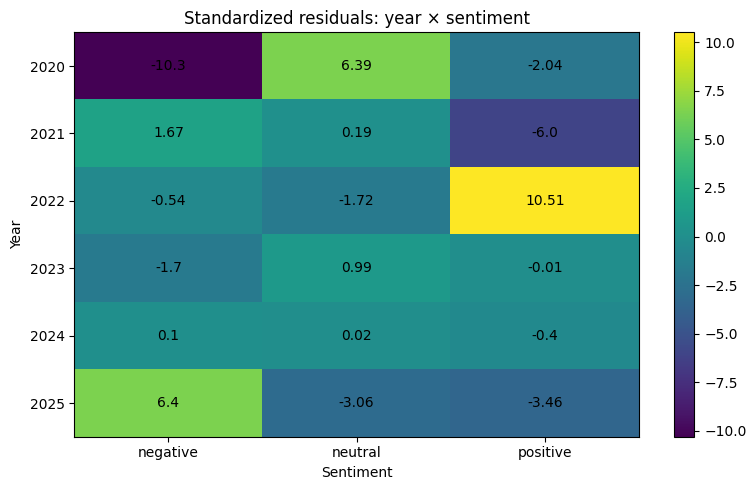

In [42]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(year_std_residuals.values, aspect="auto")

ax.set_xticks(np.arange(len(year_std_residuals.columns)))
ax.set_xticklabels(year_std_residuals.columns)

ax.set_yticks(np.arange(len(year_std_residuals.index)))
ax.set_yticklabels(year_std_residuals.index)

for i in range(year_std_residuals.shape[0]):
    for j in range(year_std_residuals.shape[1]):
        ax.text(
            j, i,
            round(year_std_residuals.iloc[i, j], 2),
            ha="center",
            va="center"
        )

ax.set_title("Standardized residuals: year × sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Year")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Sentiment distribution changes significantly over time, but the effect size is weak. The dynamics are not linear: 2020 is mostly neutral, 2022 shows an unusual increase in positive sentiment, while 2025 is the most negative year.

In [43]:
from scipy.stats import spearmanr

spearman_result = spearmanr(
    sentiment_df_main["year"],
    sentiment_df_main["sentiment_weighted"]
)

spearman_result

SignificanceResult(statistic=np.float64(-0.014271446308157708), pvalue=np.float64(5.088540974861417e-06))

Spearman correlation showed a statistically significant but extremely weak negative association between year and weighted sentiment score, ρ = -0.014, p < .001. This suggests that sentiment slightly shifts toward negativity over time, but the effect size is negligible. Therefore, the temporal dynamics should be interpreted not as a strong linear decline, but as a weak overall tendency combined with year-specific fluctuations.

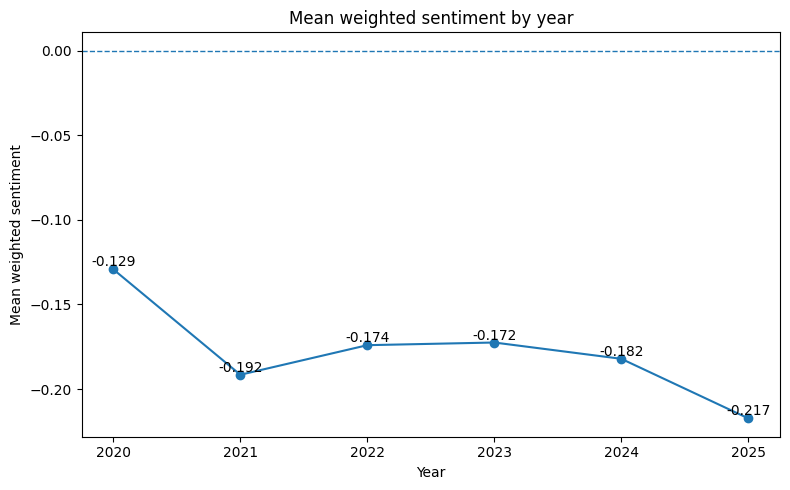

In [44]:
import matplotlib.pyplot as plt

year_mean_sentiment_main = (
    sentiment_df_main
    .groupby("year")["sentiment_weighted"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    year_mean_sentiment_main.index,
    year_mean_sentiment_main.values,
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

for year, value in year_mean_sentiment_main.items():
    plt.text(
        year,
        value,
        round(value, 3),
        ha="center",
        va="bottom"
    )

plt.title("Mean weighted sentiment by year")
plt.xlabel("Year")
plt.ylabel("Mean weighted sentiment")
plt.xticks(year_mean_sentiment_main.index)
plt.tight_layout()
plt.show()

Словари

In [1]:
!pip -q install pymorphy3 tqdm requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 59.4 MB/s eta 0:00:0000:0100:01


In [ ]:
import re
import requests
import numpy as np
import pandas as pd
import pymorphy3
from tqdm.auto import tqdm
from functools import lru_cache

morph = pymorphy3.MorphAnalyzer()


In [ ]:
url = "https://www.labinform.ru/pub/rusentilex/rusentilex_2017.txt"

raw = requests.get(url).content

try:
    text = raw.decode("utf-8")
except UnicodeDecodeError:
    text = raw.decode("cp1251")

rows = []

for line in text.splitlines():
    line = line.strip()

    if not line or line.startswith("!"):
        continue

    parts = line.split(",", 5)

    if len(parts) >= 5:
        token = parts[0].strip()
        lemma = parts[2].strip()
        sentiment = parts[3].strip()

        rows.append({
            "token": token,
            "lemma": lemma,
            "sentiment": sentiment
        })

rusentilex = pd.DataFrame(rows)

rusentilex = rusentilex[
    rusentilex["sentiment"].isin(["positive", "negative", "neutral"])
].copy()

rusentilex["score"] = rusentilex["sentiment"].map({
    "negative": -1,
    "neutral": 0,
    "positive": 1
})

rusentilex = rusentilex.drop_duplicates(subset=["lemma"])

In [4]:
lexicon = dict(zip(rusentilex["lemma"], rusentilex["score"]))

In [ ]:
@lru_cache(maxsize=200000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form


def dictionary_sentiment_score(text):
    words = re.findall(r"[а-яё]+", str(text).lower())

    if not words:
        return 0

    lemmas = [lemmatize_word(word) for word in words]
    scores = [lexicon[lemma] for lemma in lemmas if lemma in lexicon]

    if not scores:
        return 0

    return sum(scores) / len(lemmas)

In [11]:
tqdm.pandas()

sentiment_df["rusentilex_score"] = sentiment_df["text_for_sentiment"].progress_apply(
    dictionary_sentiment_score
)

  0%|          | 0/102373 [00:00<?, ?it/s]

In [12]:
sentiment_df["rusentilex_sentiment"] = np.where(
    sentiment_df["rusentilex_score"] > 0,
    "positive",
    np.where(
        sentiment_df["rusentilex_score"] < 0,
        "negative",
        "neutral"
    )
)

In [14]:
sentiment_df.to_csv(
    "/content/drive/MyDrive/Диплом_Артема_Хугаева/comments_sentiment_with_rusentilex.csv",
    index=False
)

In [15]:
sentiment_df["rusentilex_sentiment"].value_counts(normalize=True).round(3)

,proportion
rusentilex_sentiment,
negative,0.456
neutral,0.423
positive,0.121


In [18]:
sentiment_df["sentiment"].value_counts(normalize=True).round(3)

,proportion
sentiment,
neutral,0.726
negative,0.246
positive,0.027


In [19]:
rusentilex_topic_mean = (
    sentiment_df
    .groupby("topic")["rusentilex_score"]
    .mean()
    .sort_values()
)

rusentilex_topic_mean

,rusentilex_score
topic,
3,-0.033778
4,-0.033400
1,-0.029127
2,-0.028913
5,-0.021096


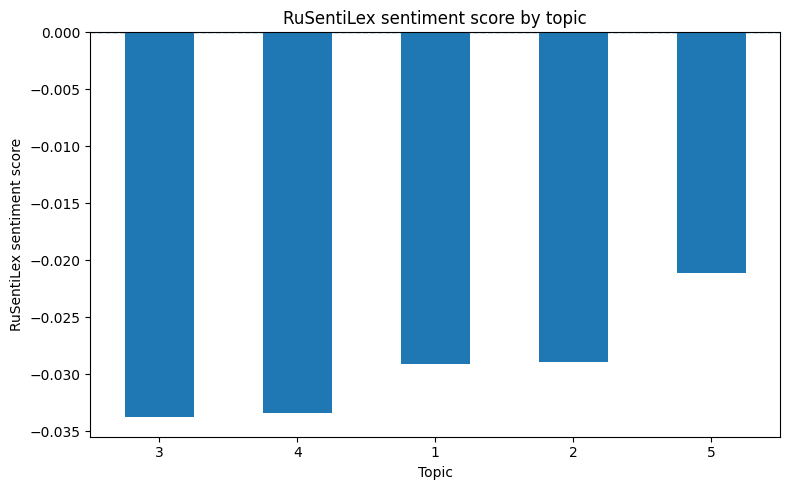

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

rusentilex_topic_mean.plot(kind="bar")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("RuSentiLex sentiment score by topic")
plt.xlabel("Topic")
plt.ylabel("RuSentiLex sentiment score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
sentiment_df_main = sentiment_df[sentiment_df["year"] < 2026].copy()
rusentilex_year_mean = (
    sentiment_df_main
    .groupby("year")["rusentilex_score"]
    .mean()
)

rusentilex_year_mean

,rusentilex_score
year,
2020,-0.028067
2021,-0.028811
2022,-0.026202
2023,-0.035533
2024,-0.033448
2025,-0.035473


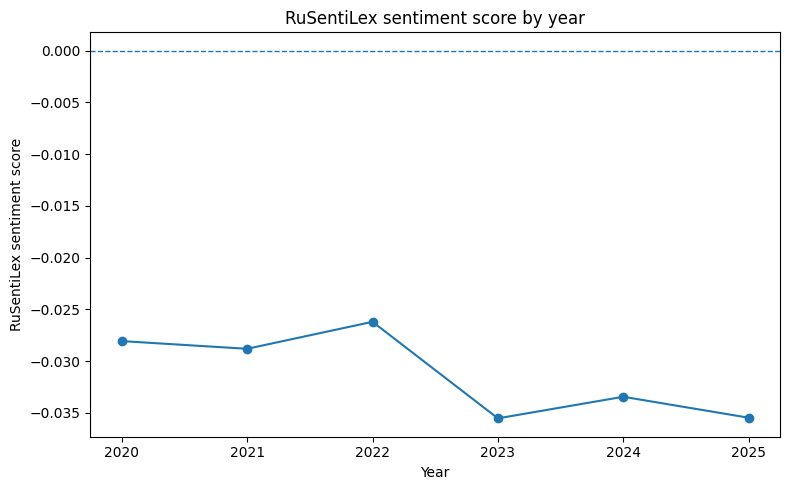

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    rusentilex_year_mean.index,
    rusentilex_year_mean.values,
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("RuSentiLex sentiment score by year")
plt.xlabel("Year")
plt.ylabel("RuSentiLex sentiment score")
plt.xticks(rusentilex_year_mean.index)
plt.tight_layout()
plt.show()

In [45]:
topic_mean_negativity = (
    sentiment_df
    .groupby("topic")["sentiment_weighted"]
    .mean()
    .mul(-1)
    .sort_values(ascending=False)
)

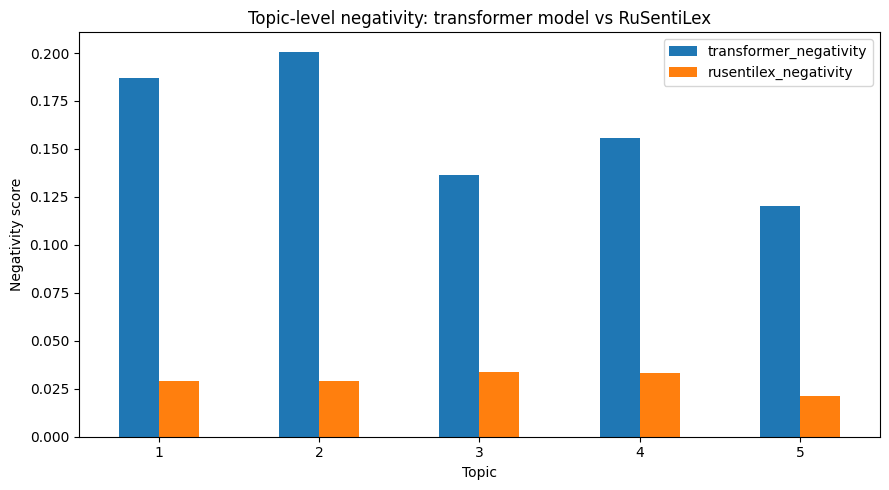

In [46]:
topic_comparison = pd.DataFrame({
    "transformer_negativity": topic_mean_negativity,
    "rusentilex_negativity": -rusentilex_topic_mean
}).sort_index()

topic_comparison.plot(kind="bar", figsize=(9, 5))

plt.title("Topic-level negativity: transformer model vs RuSentiLex")
plt.xlabel("Topic")
plt.ylabel("Negativity score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='topic'>

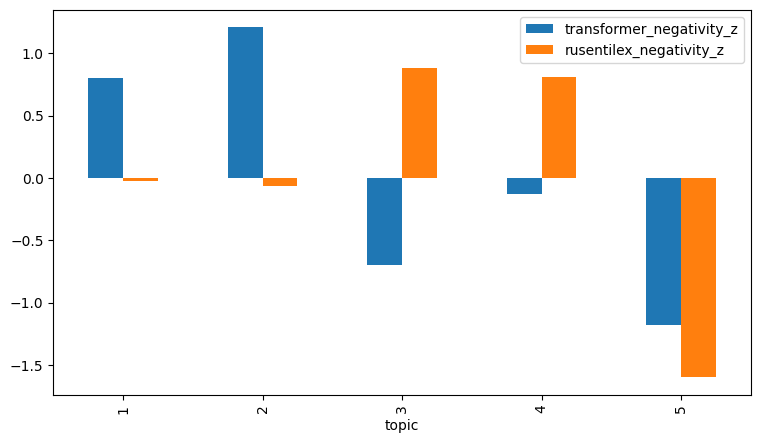

In [47]:
topic_comparison_z = topic_comparison.copy()

topic_comparison_z["transformer_negativity_z"] = (
    topic_comparison_z["transformer_negativity"] - topic_comparison_z["transformer_negativity"].mean()
) / topic_comparison_z["transformer_negativity"].std()

topic_comparison_z["rusentilex_negativity_z"] = (
    topic_comparison_z["rusentilex_negativity"] - topic_comparison_z["rusentilex_negativity"].mean()
) / topic_comparison_z["rusentilex_negativity"].std()

topic_comparison_z[
    ["transformer_negativity_z", "rusentilex_negativity_z"]
].plot(kind="bar", figsize=(9, 5))

The dictionary-based robustness check generally confirms that sentiment remains negative across topics. However, the topic-level ranking differs from the transformer model. RuSentiLex assigns stronger negativity to medical and scientific topics, probably because disease-related vocabulary is treated as negative even when used in neutral explanatory contexts. Therefore, the transformer-based model is used as the main sentiment measure, while RuSentiLex is interpreted as a supplementary robustness check.

To assess the robustness of the sentiment analysis, I compared the transformer-based sentiment model with a dictionary-based approach using RuSentiLex. Since the two methods produce scores on different scales, their topic-level negativity scores were standardized using z-scores. This made it possible to compare relative deviations from the average negativity level within each method.

The robustness check shows partial convergence between the two approaches. Both methods identify Topic 5 as the least negative topic, which suggests that this result is relatively stable. However, the methods differ in their ranking of the most negative topics. The transformer model assigns the highest negativity to Topics 1 and 2, while RuSentiLex assigns higher negativity to Topics 3 and 4.

This difference is methodologically meaningful. RuSentiLex is a dictionary-based method and is sensitive to isolated negative words, including medical vocabulary such as disease, infection, risk, or complications. As a result, it may classify medical or scientific discussions as more negative even when they are used in a neutral explanatory context. In contrast, the transformer model takes sentence-level context into account. Therefore, the transformer-based results are used as the main sentiment measure, while RuSentiLex is treated as a supplementary robustness check.